In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
def wrangle (file_path):
  """
  Reads a CSV file and returns a clean DataFrame.

  Parameters:
  file_path (str): The path to the CSV file.

  Returns:
  df (pandas.DataFrame): A clean DataFrame
  """
  df = pd.read_csv(file_path)

  # Converting 'tenure' to an int and cleaning the columns
  df['tenure'] = df['tenure'].astype(float)

  # Converting to Float
  df['TotalCharges'] = df['TotalCharges'].replace(' ', 0)
  df[['TotalCharges', 'MonthlyCharges']] = df[['TotalCharges', 'MonthlyCharges']].astype(float)

  # Filling Missing Values with Specific Mean
  df.groupby('tenure')['TotalCharges'].mean().head()
  df[['TotalCharges','MonthlyCharges']] = df[['TotalCharges','MonthlyCharges']].fillna(
      df.groupby('tenure')['TotalCharges'].mean())

  # Converting Tenure from Month to Year
  df['tenure'] = round (df['tenure'] / 12, 2)

  # Segregating Customers by tenure
  def replace_values (column):
    if column < 1:
      return 'New'
    elif column <= 3:
      return 'Mid'
    elif column > 3:
      return 'Loyal'

  df['Customer Type'] = df['tenure'].apply(replace_values)

  # Creating a Mask for 'Multiple Lines' column
  mask = df['MultipleLines'].value_counts().head(2)
  df['MultipleLines'] = df ['MultipleLines'].apply(lambda x : x if x in mask else 'N/A')

  # Creating Number of times payments occurs
  df['Payment Frequency'] = round (df['TotalCharges'] / df['MonthlyCharges'],2)

  # Mapping Yes/No Columns
  map_columns = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
  df[map_columns] = df[map_columns].replace({'Yes': 1, 'No': 0}).astype(int)

  # Columns to drop
  drop_cols = ['customerID', 'MonthlyCharges', 'SeniorCitizen', 'StreamingTV', 'tenure']
  df = df.drop(drop_cols, axis = 1)

  return df

In [3]:
file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [4]:
df = wrangle (file_path)
df.head()

/tmp/ipykernel_4337/2824772756.py:48: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[map_columns] = df[map_columns].replace({'Yes': 1, 'No': 0}).astype(int)


,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn,Customer Type,Payment Frequency
0,Female,1,0,0,N/A,DSL,No,Yes,No,No,No,Month-to-month,1,Electronic check,29.85,No,New,1.00
1,Male,0,0,1,No,DSL,Yes,No,Yes,No,No,One year,0,Mailed check,1889.50,No,Mid,33.18
2,Male,0,0,1,No,DSL,Yes,Yes,No,No,No,Month-to-month,1,Mailed check,108.15,Yes,New,2.01
3,Male,0,0,0,N/A,DSL,Yes,No,Yes,Yes,No,One year,0,Bank transfer (automatic),1840.75,No,Loyal,43.52
4,Female,0,0,1,No,Fiber optic,No,No,No,No,No,Month-to-month,1,Electronic check,151.65,Yes,New,2.14


In [5]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [6]:
# Data Splitting
from sklearn.model_selection import train_test_split
target = 'Churn'
X = df.drop(target, axis = 1)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

print (f'X_train shape: {X_train.shape}')
print (f'y_train shape: {y_train.shape}')
print (f'X_test shape: {X_test.shape}')
print (f'y_test shape: {y_test.shape}')

X_train shape: (5634, 17)
y_train shape: (5634,)
X_test shape: (1409, 17)
y_test shape: (1409,)


In [7]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier

In [8]:
cat_cols = X_train.select_dtypes('object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers = [
     ('ordinal', OrdinalEncoder(), cat_cols)
    ],
    remainder = 'passthrough'
)

In [9]:
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

clf_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('Scaling', StandardScaler()),
    ('Xg Boost', XGBClassifier(scale_pos_weight=ratio))
])

clf_2.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal', OrdinalEncoder(),
                                                  ['gender', 'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport',
                                                   'StreamingMovies',
                                                   'Contract', 'PaymentMethod',
                                                   'Customer Type'])])),
                ('Scaling', StandardScaler()),
                ('Xg Boost',
                 XGBClassifier(base_s...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [10]:
y_pred_2 = clf_2.predict(X_test)

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
# CLassification for The Second Method for Class Imbalance
print (classification_report(y_test, y_pred_2))
print ('/n')
print (confusion_matrix(y_test, y_pred_2))

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1036
           1       0.53      0.68      0.60       373

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409

/n
[[814 222]
 [120 253]]


In [12]:
# Hyper Parameter Tuning for second method
params = {
     # XGBoost Tuning
    'Xg Boost__n_estimators': [100, 200, 300],
    'Xg Boost__max_depth': [3, 4, 5],
    'Xg Boost__learning_rate': [0.01, 0.1, 0.2],
    'Xg Boost__colsample_bytree' : [0.4, 0.6, 0.8, 1],
      }

In [13]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter Tuning
model_2 = GridSearchCV(
    estimator = clf_2,
    param_grid = params,
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

model_2.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ordinal',
                                                                         OrdinalEncoder(),
                                                                         ['gender',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaymentMethod',
                                                                          'Customer '
                                                                          'Type'])])),
                                       ('Scaling', StandardScaler()),
                                       (...
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'Xg Boost__colsample_bytree': [0.4, 0.6, 0.8, 1],
                         'Xg Boost__learning_rate': [0.01, 0.1, 0.2],
                         'Xg Boost__max_depth': [3, 4, 5],
                         'Xg Boost__n_estimators': [100, 200, 300]},
             verbose=1)

In [14]:
model_2.best_params_

{'Xg Boost__colsample_bytree': 1,
 'Xg Boost__learning_rate': 0.1,
 'Xg Boost__max_depth': 5,
 'Xg Boost__n_estimators': 300}

In [15]:
# Classification of the Hyper tuned Second Method for the Actual Set
y_hyper_pred_2 = model_2.predict(X_test)
print (classification_report(y_test, y_hyper_pred_2))
print ('/n')
print (confusion_matrix(y_test, y_hyper_pred_2))

              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1036
           1       0.55      0.76      0.64       373

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409

/n
[[807 229]
 [ 90 283]]


In [16]:
# Generating Explanations
features = X_train.columns
importances = model_2.best_estimator_['Xg Boost'].feature_importances_

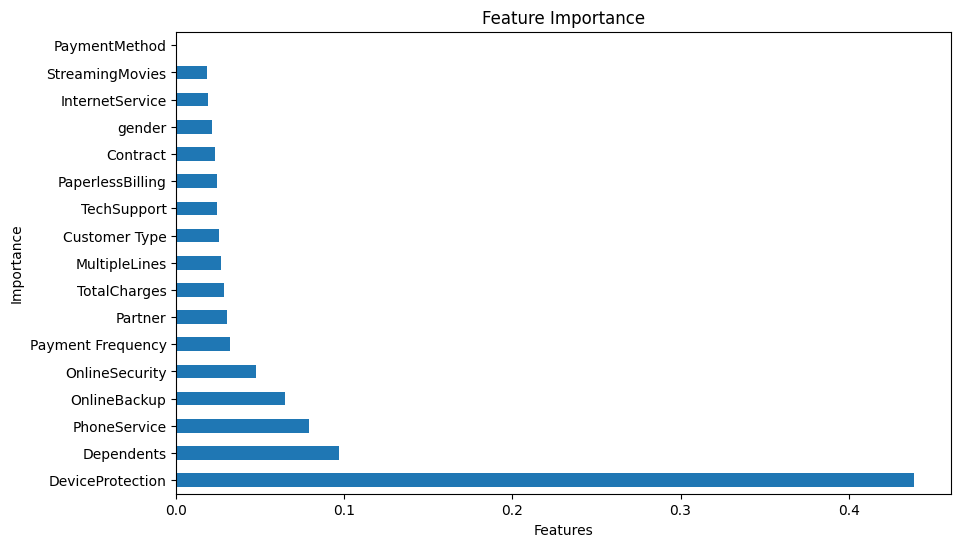

In [20]:
#Feature importances Plot
feat_imp = pd.Series(importances, index = features).sort_values(ascending = False)

#The Plot
plt.figure(figsize = (10, 6))
feat_imp.plot(kind = 'barh', title = 'Feature Importance')
plt.ylabel('Importance')
plt.xlabel('Features');

In [31]:
import shap


#Best Estimator
best_pipeline = model_2.best_estimator_

preprocessor_step = best_pipeline.named_steps['preprocessor']
scaler_step = best_pipeline.named_steps['Scaling']
xgb_model = best_pipeline.named_steps['Xg Boost']


# First: Through the categorical/numeric preprocessor
X_test_preprocessed = preprocessor_step.transform(X_test)

# Second: Through the StandardScaler
X_test_scaled = scaler_step.transform(X_test_preprocessed)

# Extract the correct feature names from the preprocessor
feature_names = preprocessor_step.get_feature_names_out()

In [32]:
# Rebuild the DataFrame
X_test_final = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

# Run SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_final)

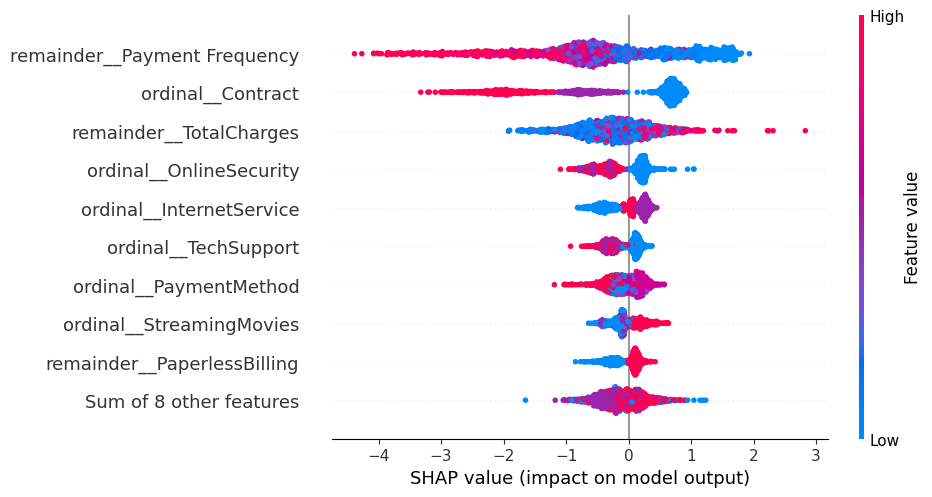

In [33]:
shap.plots.beeswarm(shap_values)